In [1]:
print("Hello world")

Hello world


IMPORTACIONES Y VARIABLES QUE DEFINEN EL MODELO

In [2]:
import tensorflow as tf
import numpy as np
import os
from fontTools.misc.classifyTools import Classifier

# MobileNetV2
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mobile

# ResNet50
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet

# InceptionV3
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input as preprocess_inception

# EfficientNetB0
# Nota: B0 es el más pequeño. Puedes subir a B1, B2... hasta B7.
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as preprocess_efficient

from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image

IMG_SHAPE = (224, 224)
BATCH_SIZE = 32 # cuantas imagenes usa de golpe para entrenar
DATASET_PATH = '../data/dataset/clasificator_data'
SAVE_MODEL_PATH = '../data/models/'

PREPARAMOS LOS DATOS

In [15]:
train_datagen = ImageDataGenerator( # VARIABLE PARA CONVERTIR LAS IMAGENES
    preprocessing_function=preprocess_input, # ESCALA LOS PIXELES COMO resnet NECESITA, SIN ESTO NO FUNCIONARIA BIEN
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2    # 20% DE LAS IMAGENES PARA VALIDACION
)

# AL TENER LAS IMAGENES DE SANAS Y ENFERMAS SEPARADAS EL FLOW_FROM_DIRECTORY NOS PERMITE CARGARLAS FACILMENTE, DETECTARA QUE QUEREMOS DIFERENCIAR DOS TIPOS DE IMAGENES QUE SERAN LAS DE NUESTRAS CARPETAS

train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SHAPE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True # MEZCLA LAS IMAGENES PARA QUE ENTRENE CON ENFERMAS Y SANAS
)

val_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SHAPE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False # NO MEZCLA LAS IMAGENES PARA QUE LA VALIDACION SEA CONSISTENTE
)

Found 1704 images belonging to 2 classes.
Found 426 images belonging to 2 classes.


CONSTRUIMOS EL MODELO

In [16]:
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.optimizers import Adam

base_model = ResNet50V2(weights='imagenet',
                        include_top=False,
                        input_shape=(224, 224, 3))

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(512, activation='relu', kernel_regularizer=l2(0.01))(x)
x = Dropout(0.5)(x)

salida = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=salida)


model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy', Precision(name='precision'), Recall(name='recall')])

#model.summary()

COMPILAMOS Y ENTRENAMOS EL MODELO

In [17]:
# ENTRENAMOS EL MODELO
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50  # PONEMOS MUCHOS EPOCHS PARA QUE SE SEPA EL DATASET AL DEDILLO, LUEGO SE PUEDE AJUSTAR
)

# Guardar
model.save(SAVE_MODEL_PATH+'discriminador_hojas_ResNet50v2.h5')

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 20s 331ms/step - accuracy: 0.7823 - loss: 8.2319 - precision: 0.7561 - recall: 0.8333 - val_accuracy: 0.9061 - val_loss: 7.6341 - val_precision: 0.9347 - val_recall: 0.8732
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 16s 302ms/step - accuracy: 0.8985 - loss: 7.1506 - precision: 0.8785 - recall: 0.9249 - val_accuracy: 0.9249 - val_loss: 6.7100 - val_precision: 0.9289 - val_recall: 0.9202
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 16s 301ms/step - accuracy: 0.9214 - loss: 6.3180 - precision: 0.9126 - recall: 0.9319 - val_accuracy: 0.9437 - val_loss: 5.9512 - val_precision: 0.9479 - val_recall: 0.9390
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 16s 301ms/step - accuracy: 0.9331 - loss: 5.6009 - precision: 0.9212 - recall: 0.9472 - val_accuracy: 0.9319 - val_loss: 5.2857 - val_precision: 0.9182 - val_recall: 0.9484
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 16s 301ms/step - accuracy: 0.9349 - loss: 5.0043 - precision: 0.9140 - recall: 0.9601 - val_accuracy: 0.9413 - val_los

PREDECIMOS UNA IMAGEN REAL DE UNA HOJA

In [3]:
MODELO_PATH = SAVE_MODEL_PATH + 'discriminador_hojas_ResNet50v2.h5'
IMAGEN_A_PROBAR = '../data/dataset/dummy_images/imagenReal_a_predecir.jpg'
IMAGEN_A_PROBAR2 = '../data/dataset/images/diseased_leaves/image (1).JPG'
IMAGEN_A_PROBAR3 = '../data/dataset/dummy_images/pimientoSano_ricos_2.jpg'

# CARGAMOS EL MODELO
print("cargando el modelo")
model = tf.keras.models.load_model(MODELO_PATH)
print("modelo cargado exitosamente!")

def cargar_y_preparar(ruta_imagen): # CAMBIAR PREPROCESS_INPUT SEGUN EL MODELO USADO
    img = image.load_img(ruta_imagen, target_size=(224, 224))
    img_array = image.img_to_array(img)

    img_array = np.expand_dims(img_array, axis=0)

    img_preprocesada = preprocess_input(img_array)

    return img_preprocesada

Cargando el modelo


¡Modelo cargado exitosamente!


In [ ]:
img_lista = cargar_y_preparar(IMAGEN_A_PROBAR3)
prediccion = model.predict(img_lista)

resultado_numerico = prediccion[0][0]

print(f"\n--- RESULTADO ---")
print(f"valor numérico: {resultado_numerico:.4f}")

# COMO EL NOMBRE DE LA CARPETA DE LAS ENFERMAS VA ANTES ALFABAETICAMENTE QUE LA DE LAS SANAS, INCEPTIONV3 DEVUELVE VALORES CERCANOS A 0 PARA ENFERMAS Y CERCANOS A 1 PARA SANAS.

# Usamos 0.5 como punto de corte.
if resultado_numerico < 0.5:
    confianza = (1 - resultado_numerico) * 100
    print(f"Diagnóstico: ENFERMA")
    print(f"Seguridad: {confianza:.2f}%")
else:
    confianza = resultado_numerico * 100
    print(f"Diagnóstico: SANA")
    print(f"Seguridad: {confianza:.2f}%")

# con IMAGEN_A_PROBAR2
#--- RESULTADO ---
#Valor numérico crudo: 0.0000
#Diagnóstico: ENFERMA
#Seguridad: 100.00%
#
# CON IMAGEN_A_PROBAR
#--- RESULTADO ---
#Valor numérico crudo: 0.0669
#Diagnóstico: ENFERMA
#Seguridad: 93.31%


VAMOS A INTENTAR HACER UNA FUNCION QUE ENTRENE UN MODELO Y NOS LO DEVUELVA PARA ASI SER MAS LIGERO EL CODIGO PARA COMPARAR DIVERSOS MODELOS

In [8]:
# TIPOS:
# 'InceptionV3', 'MobileNetV2', 'ResNet50', 'EfficientNetB0'
def crear_y_entrenar_modelo(dataset_path, model_type:str):
    ruta = SAVE_MODEL_PATH + 'discriminador_hojas_'+model_type+'.h5'
    if os.path.isfile(ruta):
        return ruta

    if model_type == 'InceptionV3':
        preprocess_input = preprocess_inception
        input_size = (299, 299)
    elif model_type == 'MobileNetV2':
        preprocess_input = preprocess_mobile
        input_size = (224, 224)
    elif model_type == 'ResNet50':
        preprocess_input = preprocess_resnet
        input_size = (224, 224)
    elif model_type == 'EfficientNetB0':
        preprocess_input = preprocess_efficient
        input_size = (224, 224)
    elif model_type == 'ResNet50v2':
        preprocess_input = preprocess_resnet_v2
        input_size = (224, 224)
    else:
        raise ValueError("Tipo de modelo no soportado. Usa 'InceptionV3', 'MobileNetV2', 'ResNet50' o 'EfficientNetB0'.")
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        horizontal_flip=True,
        validation_split=0.2
    )

    train_generator = train_datagen.flow_from_directory(
        dataset_path,
        target_size=input_size,
        batch_size=32,
        class_mode='binary',
        subset='training',
        shuffle=True
    )

    val_generator = train_datagen.flow_from_directory(
        dataset_path,
        target_size=input_size,
        batch_size=32,
        class_mode='binary',
        subset='validation',
        shuffle=False
    )
    if model_type == 'InceptionV3':
        base_model = InceptionV3(weights='imagenet',
                                include_top=False,
                                input_shape=(input_size[0], input_size[1], 3))

    elif model_type == 'MobileNetV2':
        base_model = MobileNetV2(weights='imagenet',
                                 include_top=False,
                                 input_shape=(input_size[0], input_size[1], 3))

    elif model_type == 'ResNet50':
        base_model = ResNet50(weights='imagenet',
                              include_top=False,
                              input_shape=(input_size[0], input_size[1], 3))

    elif model_type == 'EfficientNetB0':
        base_model = EfficientNetB0(weights='imagenet',
                                    include_top=False,
                                    input_shape=(input_size[0], input_size[1], 3))
    elif model_type == 'ResNet50v2':
        base_model = ResNet50V2(weights='imagenet',
                              include_top=False,
                              input_shape=(input_size[0], input_size[1], 3))
    else:
        raise ValueError("Tipo de modelo no soportado. Usa 'InceptionV3', 'MobileNetV2', 'ResNet50' o 'EfficientNetB0'.")

    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu')(x)
    x = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=x)

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=50
    )

    try:
        import h5py  # comprobar dependencia
        model.save(str(ruta))
    except Exception:
        fallback_dir = ruta.with_suffix('')
        model.save(str(fallback_dir), save_format='tf')
        ruta = fallback_dir
    return ruta

def cargar_y_preparar(ruta_imagen, target_size=(299, 299), preprocess_fn=preprocess_inception):
    img = image.load_img(ruta_imagen, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_preprocesada = preprocess_fn(img_array)
    return img_preprocesada

CREAMOS UN MODELO DE CADA TIPO Y CREAMOS UNA TABLA DONDE ALMACENAREMOS EL RESULTADO DE LA PREDICCION DE CADA UNO

In [9]:
from tensorflow.keras.applications.resnet_v2 import preprocess_input as preprocess_resnet_v2
from tensorflow.keras.applications import ResNet50V2

IMAGEN_A_PROBAR = '../data/dataset/dummy_images/imagenReal_a_predecir.jpg'
IMAGEN_A_PROBAR2 = '../data/dataset/images/diseased_leaves/image (1).JPG'
IMAGEN_A_PROBAR3 = '../data/dataset/dummy_images/pimientoSano_ricos_2.jpg'

model_types = ['InceptionV3', 'MobileNetV2', 'ResNet50', 'EfficientNetB0', 'ResNet50v2']
results = {}

INPUT_SIZES = {
    'InceptionV3': (299, 299),
    'MobileNetV2': (224, 224),
    'ResNet50': (224, 224),
    'EfficientNetB0': (224, 224),
    'ResNet50v2': (224, 224)
}
PREPROCESSORS = {
    'InceptionV3': preprocess_inception,
    'MobileNetV2': preprocess_mobile,
    'ResNet50': preprocess_resnet,
    'EfficientNetB0': preprocess_efficient,
    'ResNet50v2': preprocess_resnet_v2
}

for model_type in model_types:
    print(f"\nEntrenando modelo: {model_type}")
    ruta_modelo = crear_y_entrenar_modelo(DATASET_PATH, model_type)

    input_size = INPUT_SIZES.get(model_type)
    preprocess_fn = PREPROCESSORS.get(model_type)

    img_lista = cargar_y_preparar(IMAGEN_A_PROBAR, target_size=input_size, preprocess_fn=preprocess_fn)
    model = tf.keras.models.load_model(ruta_modelo)
    prediccion = model.predict(img_lista)
    resultado_numerico = prediccion[0][0]
    results[model_type] = resultado_numerico

print(results)



Entrenando modelo: InceptionV3
Found 1704 images belonging to 2 classes.
Found 426 images belonging to 2 classes.
Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 29s 498ms/step - accuracy: 0.8069 - loss: 0.4661 - val_accuracy: 0.6737 - val_loss: 0.7472
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 25s 457ms/step - accuracy: 0.9137 - loss: 0.2164 - val_accuracy: 0.8615 - val_loss: 0.3307
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 25s 458ms/step - accuracy: 0.9143 - loss: 0.1958 - val_accuracy: 0.9366 - val_loss: 0.1673
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 25s 460ms/step - accuracy: 0.9384 - loss: 0.1577 - val_accuracy: 0.9366 - val_loss: 0.1700
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 25s 460ms/step - accuracy: 0.9378 - loss: 0.1521 - val_accuracy: 0.9085 - val_loss: 0.2223
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 25s 459ms/step - accuracy: 0.9525 - loss: 0.1268 - val_accuracy: 0.9343 - val_loss: 0.1549
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 25s 462ms/step - accuracy: 0.9513 - loss: 0.1249 - val_accuracy: 0.9155 -

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 719ms/step

Entrenando modelo: MobileNetV2
Found 1704 images belonging to 2 classes.
Found 426 images belonging to 2 classes.
Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 228ms/step - accuracy: 0.8656 - loss: 0.4110 - val_accuracy: 0.9343 - val_loss: 0.1700
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 12s 216ms/step - accuracy: 0.9536 - loss: 0.1246 - val_accuracy: 0.9554 - val_loss: 0.1100
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 12s 214ms/step - accuracy: 0.9707 - loss: 0.0780 - val_accuracy: 0.9577 - val_loss: 0.1139
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 12s 214ms/step - accuracy: 0.9748 - loss: 0.0665 - val_accuracy: 0.9460 - val_loss: 0.1321
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 12s 215ms/step - accuracy: 0.9783 - loss: 0.0525 - val_accuracy: 0.9437 - val_loss: 0.1446
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 12s 216ms/step - accuracy: 0.9730 - loss: 0.0732 - val_accuracy: 0.9507 - val_loss: 0.1714
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 12s 214ms/step - accuracy: 0.9759 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step

Entrenando modelo: ResNet50
Found 1704 images belonging to 2 classes.
Found 426 images belonging to 2 classes.
Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 22s 368ms/step - accuracy: 0.9155 - loss: 0.2385 - val_accuracy: 0.9742 - val_loss: 0.0956
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 19s 352ms/step - accuracy: 0.9824 - loss: 0.0483 - val_accuracy: 0.9671 - val_loss: 0.1480
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 19s 351ms/step - accuracy: 0.9718 - loss: 0.0788 - val_accuracy: 0.9366 - val_loss: 0.2909
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 19s 351ms/step - accuracy: 0.9812 - loss: 0.0515 - val_accuracy: 0.9648 - val_loss: 0.1127
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 19s 352ms/step - accuracy: 0.9877 - loss: 0.0301 - val_accuracy: 0.9671 - val_loss: 0.1047
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 19s 351ms/step - accuracy: 0.9888 - loss: 0.0297 - val_accuracy: 0.9765 - val_loss: 0.0974
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 19s 352ms/step - accuracy: 0.9859 - l

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 609ms/step

Entrenando modelo: EfficientNetB0
Found 1704 images belonging to 2 classes.
Found 426 images belonging to 2 classes.
Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 18s 269ms/step - accuracy: 0.9061 - loss: 0.2175 - val_accuracy: 0.9554 - val_loss: 0.1346
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 247ms/step - accuracy: 0.9712 - loss: 0.0841 - val_accuracy: 0.9531 - val_loss: 0.1120
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 248ms/step - accuracy: 0.9630 - loss: 0.0961 - val_accuracy: 0.9648 - val_loss: 0.0863
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 250ms/step - accuracy: 0.9648 - loss: 0.0870 - val_accuracy: 0.9648 - val_loss: 0.1152
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 247ms/step - accuracy: 0.9894 - loss: 0.0358 - val_accuracy: 0.9577 - val_loss: 0.0945
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 247ms/step - accuracy: 0.9912 - loss: 0.0263 - val_accuracy: 0.9624 - val_loss: 0.1016
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 248ms/step - accuracy: 0.98

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 711ms/step

Entrenando modelo: ResNet50v2
Found 1704 images belonging to 2 classes.
Found 426 images belonging to 2 classes.
Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 19s 320ms/step - accuracy: 0.8480 - loss: 0.4479 - val_accuracy: 0.9131 - val_loss: 0.1905
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 16s 301ms/step - accuracy: 0.9460 - loss: 0.1331 - val_accuracy: 0.9319 - val_loss: 0.1805
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 16s 302ms/step - accuracy: 0.9542 - loss: 0.1109 - val_accuracy: 0.9437 - val_loss: 0.1115
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 16s 303ms/step - accuracy: 0.9671 - loss: 0.0892 - val_accuracy: 0.9577 - val_loss: 0.1015
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 16s 302ms/step - accuracy: 0.9718 - loss: 0.0824 - val_accuracy: 0.9507 - val_loss: 0.1293
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 16s 303ms/step - accuracy: 0.9765 - loss: 0.0625 - val_accuracy: 0.9624 - val_loss: 0.0939
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 16s 298ms/step - accuracy: 0.9712 -

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 556ms/step
{'InceptionV3': np.float32(0.0049316585), 'MobileNetV2': np.float32(9.606803e-07), 'ResNet50': np.float32(2.1309094e-07), 'EfficientNetB0': np.float32(0.0006380369), 'ResNet50v2': np.float32(0.040401187)}


# se testeará cual de estos modelos es mejor y se analizarán los campos necesarios para dar el veredicto


Evaluando InceptionV3...


Found 495 images belonging to 2 classes.
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 335ms/step
true positives: 287, false negatives: 8, true negatives: 197, false positives: 3


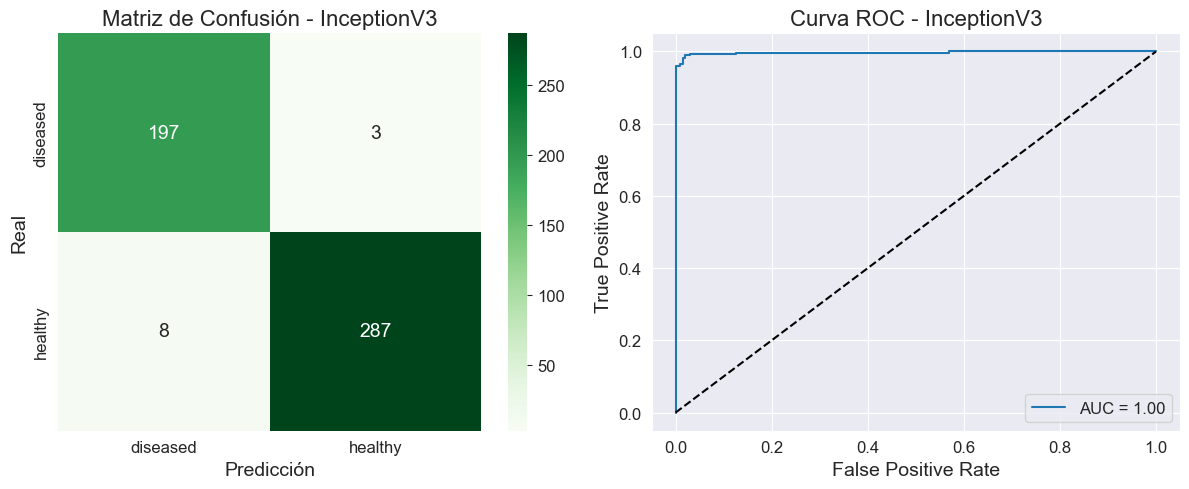

Evaluando MobileNetV2...


Found 495 images belonging to 2 classes.
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step
true positives: 293, false negatives: 2, true negatives: 191, false positives: 9


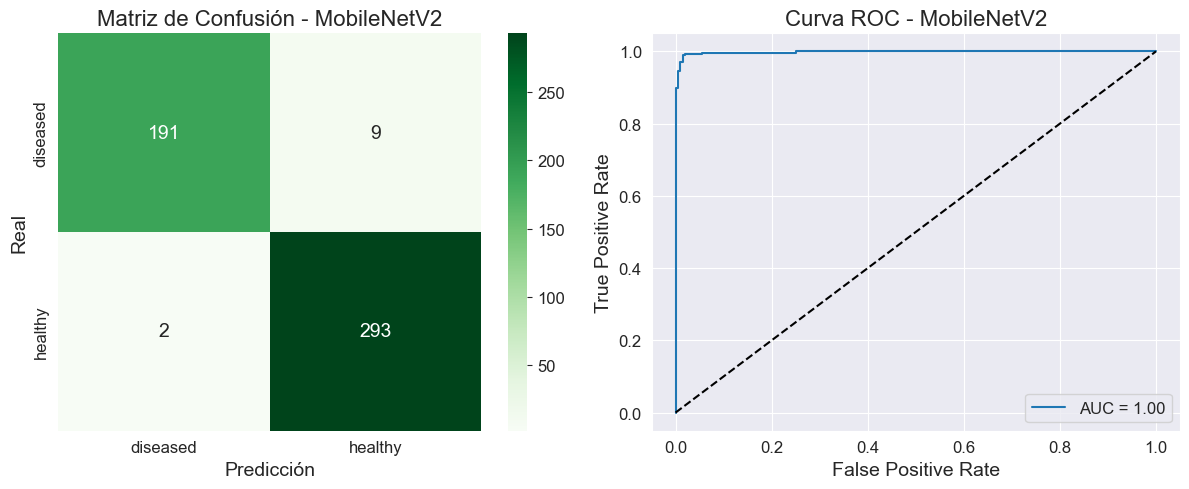

Evaluando ResNet50...


Found 495 images belonging to 2 classes.
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 289ms/step
true positives: 293, false negatives: 2, true negatives: 200, false positives: 0


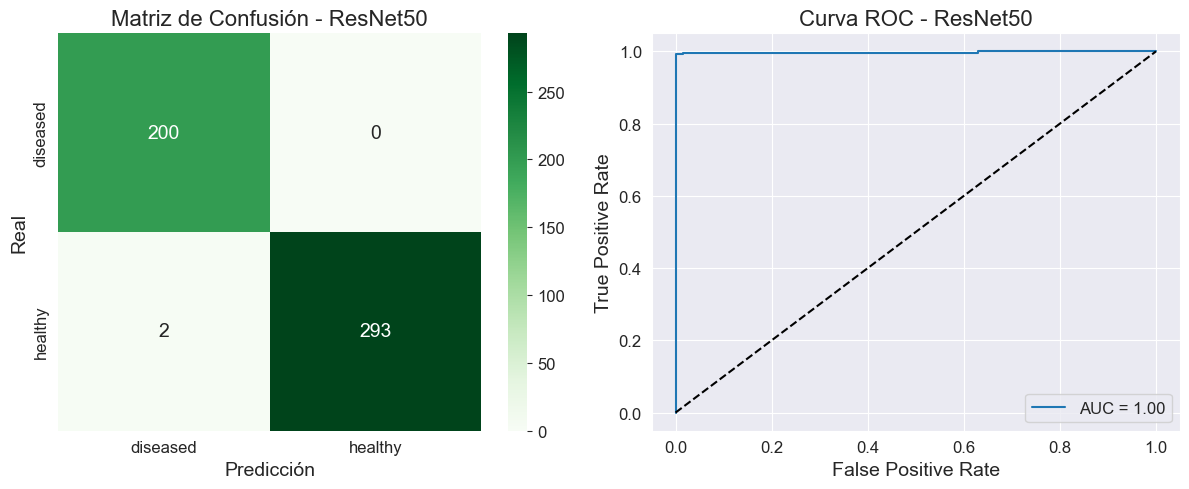

Evaluando EfficientNetB0...


Found 495 images belonging to 2 classes.
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 164ms/step
true positives: 291, false negatives: 4, true negatives: 197, false positives: 3


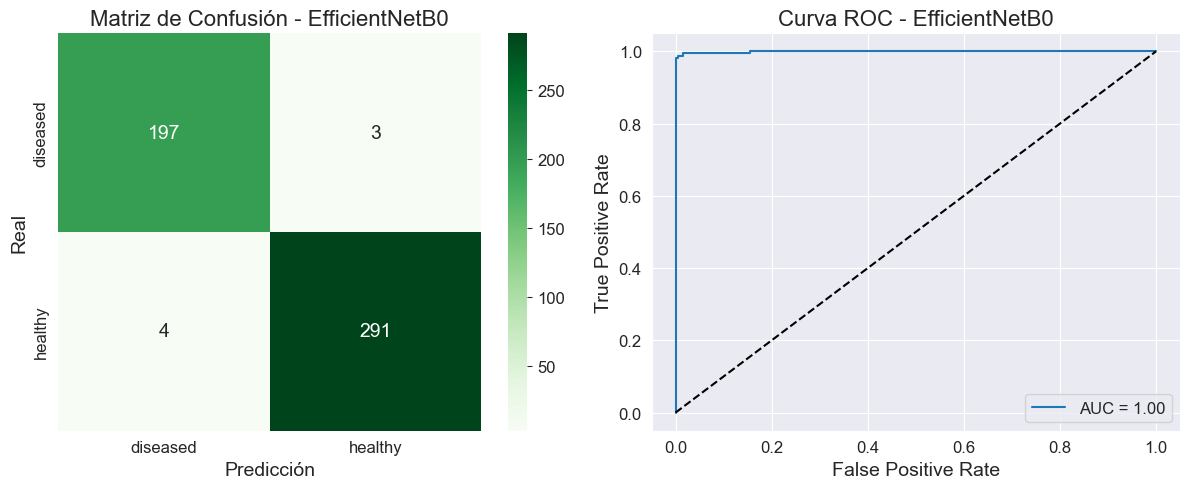

Evaluando ResNet50v2...


Found 495 images belonging to 2 classes.
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 281ms/step
true positives: 295, false negatives: 0, true negatives: 0, false positives: 200


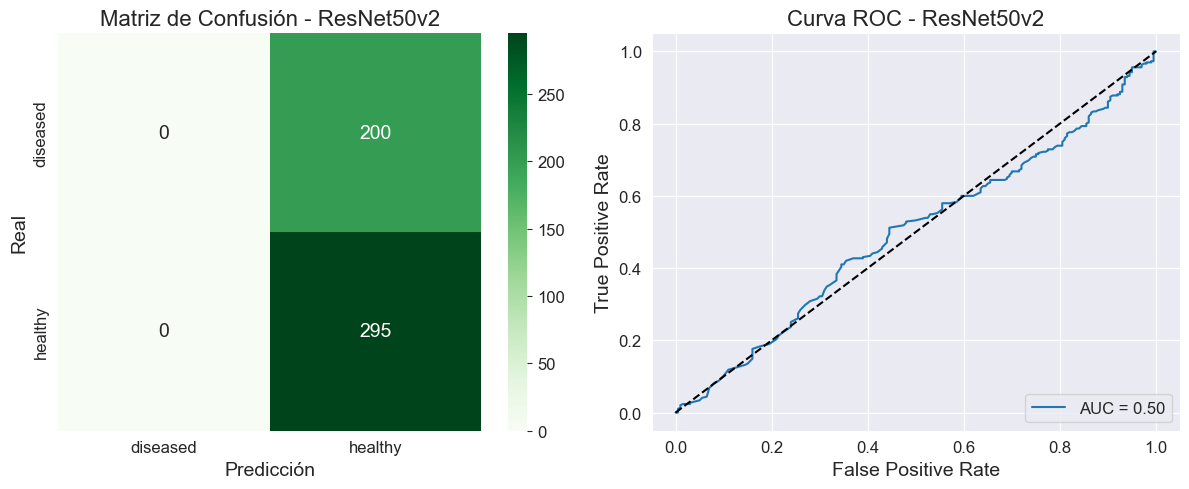


--- TABLA COMPARATIVA FINAL ---
           Modelo  Accuracy  Precision    Recall  F1-Score  \
2        ResNet50  0.995960   1.000000  0.993220  0.996599   
3  EfficientNetB0  0.985859   0.989796  0.986441  0.988115   
1     MobileNetV2  0.977778   0.970199  0.993220  0.981575   
0     InceptionV3  0.977778   0.989655  0.972881  0.981197   
4      ResNet50v2  0.595960   0.595960  1.000000  0.746835   

   False Positive Rate  Inferencia (ms/img)  Tamaño (MB)  
2                0.000            11.077967   114.568054  
3                0.015             6.791563    31.172203  
1                0.045             4.880000    24.153229  
0                0.015            13.055941   108.136406  
4                1.000            10.726181   114.568054  


In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    roc_curve, auc, precision_recall_fscore_support
)
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

DATASET_PATH = '../data/dataset/clasificator_data'
MODEL_DIR = '../data/models/'
BATCH_SIZE = 32

MODEL_CONFIGS = {
    'InceptionV3': {'size': (299, 299), 'preprocess': tf.keras.applications.inception_v3.preprocess_input},
    'MobileNetV2': {'size': (224, 224), 'preprocess': tf.keras.applications.mobilenet_v2.preprocess_input},
    'ResNet50': {'size': (224, 224), 'preprocess': tf.keras.applications.resnet50.preprocess_input},
    'EfficientNetB0': {'size': (224, 224), 'preprocess': tf.keras.applications.efficientnet.preprocess_input},
    'ResNet50v2': {'size': (224, 224), 'preprocess': tf.keras.applications.resnet_v2.preprocess_input},
}

def evaluar_modelos(model_names):
    comparativa_final = []

    for name in model_names:
        print(f"Evaluando {name}...")
        config = MODEL_CONFIGS[name]
        model_path = os.path.join(MODEL_DIR, f"discriminador_hojas_{name}.h5")

        if not os.path.exists(model_path):
            print(f"Modelo {name} no encontrado en {model_path}. Nos lo saltamos")
            continue

        model = tf.keras.models.load_model(model_path)

        test_datagen = ImageDataGenerator(
            preprocessing_function=config['preprocess'],
            validation_split=0.2
        )

        mis_clases = ['diseased', 'healthy']

        test_generator = test_datagen.flow_from_directory(
            DATASET_PATH,
            target_size=config['size'],
            batch_size=BATCH_SIZE,
            classes=mis_clases,
            class_mode='binary',
            subset='validation',
            shuffle=False
        )

        # time
        start_time = time.time()
        y_pred_probs = model.predict(test_generator)
        end_time = time.time()

        total_imgs = len(test_generator.filenames)
        inference_time_per_img = (end_time - start_time) / total_imgs
        model_size_mb = os.path.getsize(model_path) / (1024 * 1024)

        y_true = test_generator.classes
        y_pred = (y_pred_probs > 0.5).astype(int).flatten()
        cm = confusion_matrix(y_true, y_pred)

        tp = cm[1, 1]
        fn = cm[1, 0]
        tn = cm[0, 0]
        fp = cm[0, 1]

        print(f"true positives: {tp}, false negatives: {fn}, true negatives: {tn}, false positives: {fp}")

        fpr = fp / (tn + fp) if (tn + fp) > 0 else 0
        precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
        acc = np.mean(y_true == y_pred)

        # Guardar resultados
        comparativa_final.append({
            'Modelo': name,
            'Accuracy': acc,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1,
            'False Positive Rate': fpr,
            'Inferencia (ms/img)': inference_time_per_img * 1000,
            'Tamaño (MB)': model_size_mb
        })

        # 4. Generar Gráficas (Matriz de Confusión y ROC)
        generar_graficas_modelo(name, y_true, y_pred, y_pred_probs, test_generator.class_indices)

    return pd.DataFrame(comparativa_final)

def generar_graficas_modelo(name, y_true, y_pred, y_probs, class_indices):
    title_font = 16
    label_font = 14
    tick_font = 12
    annot_font = 14
    legend_font = 12

    plt.figure(figsize=(12, 5))

    ax1 = plt.subplot(1, 2, 1)
    cm = confusion_matrix(y_true, y_pred)
    hm = sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Greens',
        xticklabels=class_indices.keys(),
        yticklabels=class_indices.keys(),
        annot_kws={'fontsize': annot_font},
        ax=ax1
    )
    ax1.set_title(f'Matriz de Confusión - {name}', fontsize=title_font)
    ax1.set_ylabel('Real', fontsize=label_font)
    ax1.set_xlabel('Predicción', fontsize=label_font)
    ax1.tick_params(axis='both', labelsize=tick_font)

    if hm.collections:
        cbar = hm.collections[0].colorbar
        if cbar is not None:
            cbar.ax.tick_params(labelsize=tick_font)

    ax2 = plt.subplot(1, 2, 2)
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)
    ax2.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
    ax2.plot([0, 1], [0, 1], 'k--')
    ax2.set_title(f'Curva ROC - {name}', fontsize=title_font)
    ax2.set_xlabel('False Positive Rate', fontsize=label_font)
    ax2.set_ylabel('True Positive Rate', fontsize=label_font)
    ax2.tick_params(axis='both', labelsize=tick_font)
    ax2.legend(loc='lower right', fontsize=legend_font)

    plt.tight_layout()
    plt.savefig(f'clasificator_plots/{name}_evaluation.png')
    plt.show()

# Ejecución
modelos_a_testear = ['InceptionV3', 'MobileNetV2', 'ResNet50', 'EfficientNetB0',  'ResNet50v2']
df_resultados = evaluar_modelos(modelos_a_testear)

# Mostrar tabla final comparativa
print("\n--- TABLA COMPARATIVA FINAL ---")
print(df_resultados.sort_values(by='F1-Score', ascending=False))

In [26]:
ruta_modelo = crear_y_entrenar_modelo(DATASET_PATH, 'ResNet50')

input_size = (224, 224)
preprocess_fn = preprocess_resnet

img_lista = cargar_y_preparar(IMAGEN_A_PROBAR, target_size=input_size, preprocess_fn=preprocess_fn)
model = tf.keras.models.load_model(ruta_modelo)

Found 1704 images belonging to 2 classes.
Found 426 images belonging to 2 classes.
Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 22s 373ms/step - accuracy: 0.8680 - loss: 0.4530 - val_accuracy: 0.9460 - val_loss: 0.1424
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 19s 349ms/step - accuracy: 0.9736 - loss: 0.0770 - val_accuracy: 0.9413 - val_loss: 0.1656
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 19s 349ms/step - accuracy: 0.9765 - loss: 0.0620 - val_accuracy: 0.9601 - val_loss: 0.1147
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 20s 370ms/step - accuracy: 0.9877 - loss: 0.0367 - val_accuracy: 0.9601 - val_loss: 0.0983
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 20s 370ms/step - accuracy: 0.9918 - loss: 0.0289 - val_accuracy: 0.9718 - val_loss: 0.0620
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 22s 409ms/step - accuracy: 0.9888 - loss: 0.0294 - val_accuracy: 0.9671 - val_loss: 0.1269
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 22s 407ms/step - accuracy: 0.9953 - loss: 0.0215 - val_accuracy: 0.9695 - val_loss: 0.0745
Epoch 8/50
54/